In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta_archivo = '/content/drive/MyDrive/Colab Notebooks/PS_20174392719_1491204439457_log.csv'

datos = pd.read_csv(ruta_archivo)
datos.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
# Tamaño del dataset
print("Tamaño del dataset (Filas, Columnas):")
print(datos.shape)
print("-" * 30)

# Normales vs Fraude
fraudes = datos[datos['isFraud'] == 1]
normales = datos[datos['isFraud'] == 0]
print("Número de transacciones normales:", normales.shape[0])
print("Número de transacciones con fraude:", fraudes.shape[0])

Tamaño del dataset (Filas, Columnas):
(1927241, 11)
------------------------------
Número de transacciones normales: 1925338
Número de transacciones con fraude: 1902


In [ ]:
# Tipos de transacciones usan los defraudadores
print("Distribucion en transacciones normales:")
print(datos[datos['isFraud'] == 0]['type'].value_counts())
print("-" * 30)
print("Distribucion en transacciones con fraude:")
print(datos.groupby('type')['isFraud'].sum())

Distribucion en transacciones normales:
type
CASH_OUT    686680
PAYMENT     644101
CASH_IN     423454
TRANSFER    158416
DEBIT        12687
Name: count, dtype: int64
------------------------------
Distribucion en transacciones con fraude:
type
CASH_IN       0.0
CASH_OUT    958.0
DEBIT         0.0
PAYMENT       0.0
TRANSFER    944.0
Name: isFraud, dtype: float64


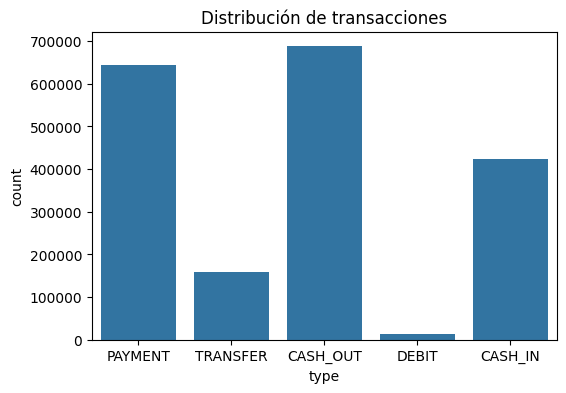

In [ ]:
# Grafico de transacciones
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=datos)
plt.title('Distribución de transacciones')
plt.show()

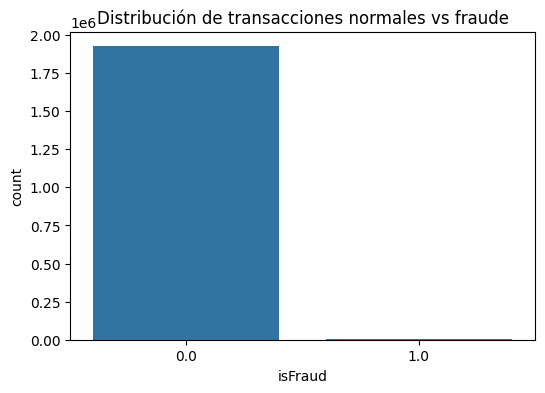

In [ ]:
# Gráfico de operaciones normales vs fraude
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=datos)
plt.title('Distribución de transacciones normales vs fraude')
plt.show()

In [ ]:
# Filtramos el dataset con TRANSFER y CASH_OUT
datos_riesgo = datos[datos['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print("Tamaño del dataset original:", datos.shape)
print("Tamaño del dataset filtrado (TRANSFER y CASH_OUT):", datos_riesgo.shape)
print("-" * 30)

# Verificamos que no hemos perdido ningun fraude
print("Fraudes en el nuevo dataset:")
print(datos_riesgo['isFraud'].sum())

Tamaño del dataset original: (1927241, 11)
Tamaño del dataset filtrado (TRANSFER y CASH_OUT): (846999, 11)
------------------------------
Fraudes en el nuevo dataset:
1902.0


In [ ]:
# Nueva columna para ver si la cuenta de origen se ha quedado a cero (1 si se vació, 0 si aún le queda dinero)
datos_riesgo['cuenta_vaciada'] = (datos_riesgo['newbalanceOrig'] == 0).astype(int)
# Transformación de variables categóricas a numéricas
datos_riesgo['type_num'] = datos_riesgo['type'].map({'TRANSFER': 1, 'CASH_OUT': 2})

In [ ]:
# AGENTE ANALITICO (ISOLATION FOREST)
# Variables elegidas
columnas_modelo = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'cuenta_vaciada', 'type_num']
X = datos_riesgo[columnas_modelo]

# Entrenamiento del modelo
modelo_isolation = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
datos_riesgo['anomaly_score'] = modelo_isolation.fit_predict(X)

In [ ]:
# AGENTE DOCUMENTAL
anomalias = datos_riesgo[datos_riesgo['anomaly_score'] == -1].copy()
top20_fraude = anomalias.sort_values(by='amount', ascending=False).head(20)
print("-" * 60)
print("ANÁLISIS COMPLETADO EXITOSAMENTE")
print(f"De {len(datos_riesgo)} operaciones sospechosas, la IA ha aislado {len(anomalias)} anomalías.")
print("-" * 60)
print("TOP 20 ANOMALÍAS PARA REVISIÓN DEL SOCIO:")
columnas_visibles = ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'cuenta_vaciada']
print(top20_fraude[columnas_visibles])

------------------------------------------------------------
ANÁLISIS COMPLETADO EXITOSAMENTE
De 846999 operaciones sospechosas, la IA ha aislado 8469 anomalías.
------------------------------------------------------------
TOP 20 ANOMALÍAS PARA REVISIÓN DEL SOCIO:
         step      type      amount  oldbalanceOrg  newbalanceOrig  \
1141252   131  CASH_OUT  10000000.0    10000000.00            0.00   
1237396   134  CASH_OUT  10000000.0    10000000.00            0.00   
1237395   134  TRANSFER  10000000.0    13892156.30      3892156.30   
1054999    96  TRANSFER  10000000.0    18267760.50      8267760.50   
1030710    86  CASH_OUT  10000000.0    10000000.00            0.00   
1059699   118  CASH_OUT  10000000.0    10000000.00            0.00   
1059698   118  TRANSFER  10000000.0    11812161.42      1812161.42   
481250     19  TRANSFER  10000000.0    11861008.32      1861008.32   
481251     19  CASH_OUT  10000000.0    10000000.00            0.00   
1141251   131  TRANSFER  10000000.0

In [ ]:
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt

------------------------------------------------------------
RADIOGRAFÍA DEL SOSPECHOSO NÚMERO 1:
Datos de la transacción:
step                     131
type                CASH_OUT
amount            10000000.0
cuenta_vaciada             1
------------------------------------------------------------


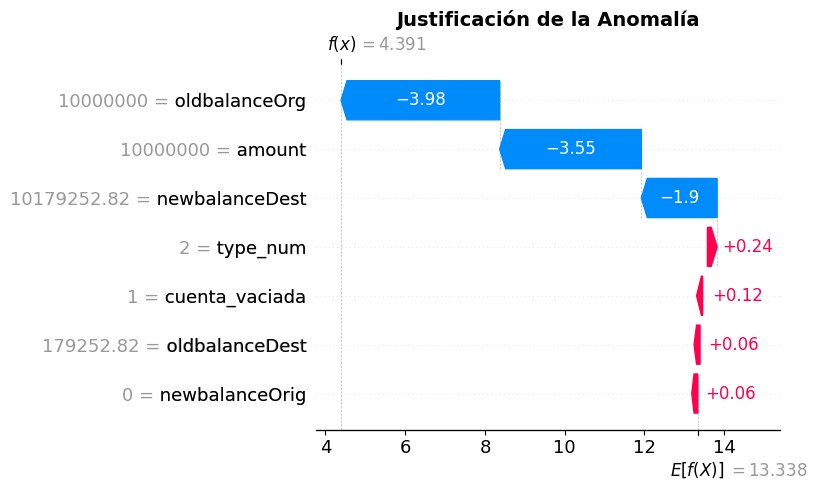

In [ ]:
# Creamos el Traductor
explainer = shap.TreeExplainer(modelo_isolation)

# Aislamos los datos del sospechoso
sospechoso_num_1 = top20_fraude[columnas_modelo].iloc[[0]]

# Calculamos los valores SHAP
shap_values = explainer(sospechoso_num_1)

# Visualizamos los valores SHAP
print("-" * 60)
print("RADIOGRAFÍA DEL SOSPECHOSO NÚMERO 1:")
print("Datos de la transacción:")
print(top20_fraude[['step', 'type', 'amount', 'cuenta_vaciada']].iloc[0].to_string())
print("-" * 60)

# Dibujamos el grafico de cascada
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title('Justificación de la Anomalía', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
!pip install google-genai

In [ ]:
from google import genai
from google.colab import userdata

# Configuración del modelo
api_key = userdata.get('GOOGLE_API_KEY')
client = genai.Client(api_key=api_key)

In [ ]:
# Función redactar informe
def redactar_informe_auditoria(transaccion, motivo_shap):
    """
    Función modular para generar la narrativa del papel de trabajo.
    """

    # Extraemos los datos para el contexto
    tipo = transaccion['type']
    importe = f"{transaccion['amount']:,.2f} €"
    saldo_orig = f"{transaccion['oldbalanceOrg']:,.2f} €"
    vaciado = "SÍ" if transaccion['cuenta_vaciada'] == 1 else "NO"

    # Construcción del Prompt Maestro
    prompt = f"""
    ACTÚA COMO: Socio de Auditoría Senior experto en NIA 240.
    CONTEXTO: Estamos realizando un Journal Entry Testing (JET) con IA.

    DATOS DE LA TRANSACCIÓN:
    - Tipo: {tipo}
    - Importe: {importe}
    - Saldo Origen previo: {saldo_orig}
    - ¿Cuenta vaciada por completo?: {vaciado}

    JUSTIFICACIÓN TÉCNICA (SHAP):
    {motivo_shap}

    TAREA: Redacta la narrativa para el Papel de Trabajo de Auditoría.
    FORMATO DE SALIDA (ESTRICTO):
    1. EXPLICACIÓN BREVE: Resumen de la anomalía.
    2. FACTORES CLAVE: Lista de por qué es sospechosa.
    3. NIVEL DE RIESGO: (Alto/Medio/Bajo) y por qué.
    4. CONCLUSIÓN NIA 240: Justificación de por qué se incluye en la muestra.

    REGLA DE ORO: No inventes datos. Sé sobrio y profesional.
    """

    # Nueva forma de llamar al modelo
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt
    )
    return response.text

In [ ]:
# --- EJECUCIÓN PARA EL SOSPECHOSO NÚMERO 1 ---
# Cogemos los datos del primer sospechoso de tu Top 20
sospechoso_num_1 = top20_fraude.iloc[0]

# Definimos el motivo SHAP visualmente extraído
explicacion_visual = "El modelo detectó una anomalía extrema debido a que el importe de la transacción coincide exactamente con el saldo total de la cuenta, resultando en un vaciado inmediato."

print("El Agente Documental está redactando el informe...")
informe_final = redactar_informe_auditoria(sospechoso_num_1, explicacion_visual)

print("\n" + "="*50)
print("BORRADOR PARA PAPEL DE TRABAJO")
print("="*50 + "\n")
print(informe_final)

El Agente Documental está redactando el informe...

BORRADOR PARA PAPEL DE TRABAJO

**NARRATIVA PARA PAPEL DE TRABAJO DE AUDITORÍA**

---

**1. EXPLICACIÓN BREVE:**
El sistema de Journal Entry Testing (JET) basado en IA ha identificado una transacción de tipo CASH_OUT por un importe de 10,000,000.00 €. La anomalía detectada radica en que este importe coincide exactamente con el saldo previo de la cuenta de origen (10,000,000.00 €), lo que resultó en el vaciado completo e inmediato de la misma. El modelo SHAP categorizó esta operación como una anomalía extrema.

**2. FACTORES CLAVE:**
*   Coincidencia exacta del importe de la transacción con el saldo total de la cuenta de origen.
*   Vaciado completo e inmediato de una cuenta con un saldo significativo.
*   Naturaleza de la operación (CASH_OUT) por un importe elevado (€10,000,000.00).
*   Clasificación por la IA como "anomalía extrema", sugiriendo una desviación significativa del comportamiento transaccional esperado.

**3. NIVEL DE RIE